In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

In [4]:
qnn = np.load('./QNN/interactions.npz', allow_pickle=True)
vqe = np.load('./VQE/interactions.npz', allow_pickle=True)

In [5]:
print(vqe['7n2i'])

[[ 0.    0.    0.    0.   -3.01 -2.31 -1.87 -4.13 -2.08]
 [ 0.    0.    0.    0.    0.   -2.01 -1.57 -4.02 -1.96]
 [ 0.    0.    0.    0.    0.    0.   -1.9  -4.28 -2.12]
 [ 0.    0.    0.    0.    0.    0.    0.   -6.29 -3.46]
 [ 0.    0.    0.    0.    0.    0.    0.    0.   -3.01]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.  ]]


In [6]:
pdb_ids = vqe.files

  0%|          | 0/9 [00:00<?, ?it/s]

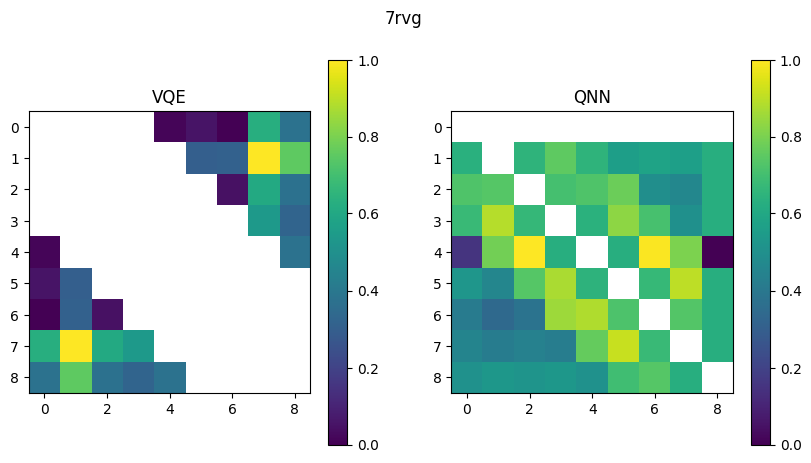

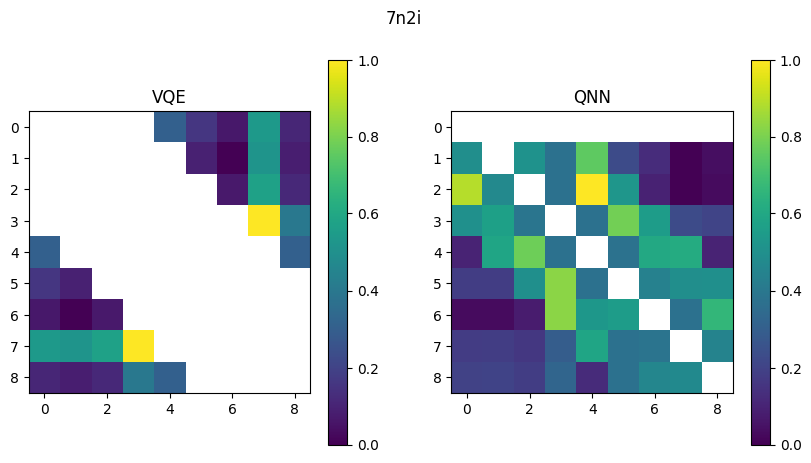

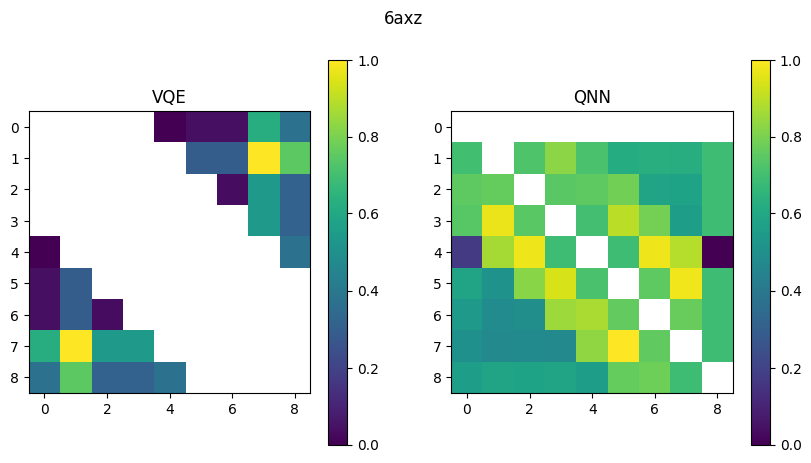

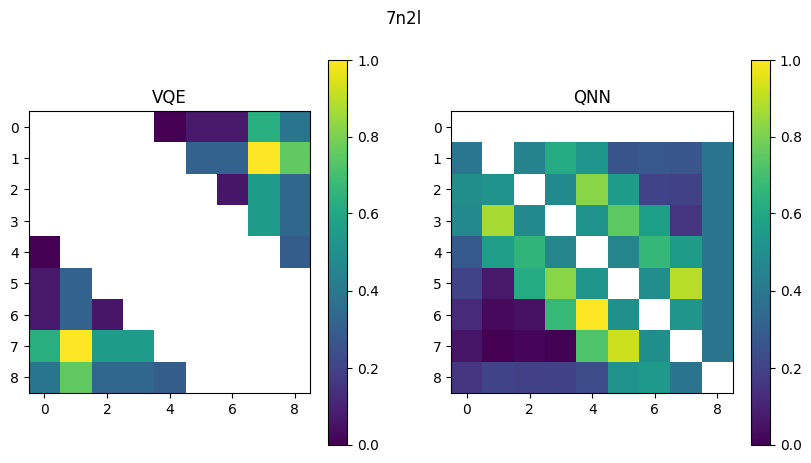

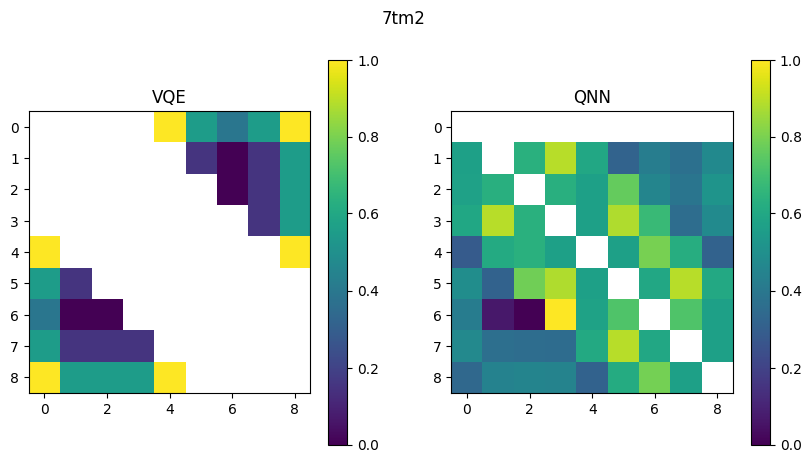

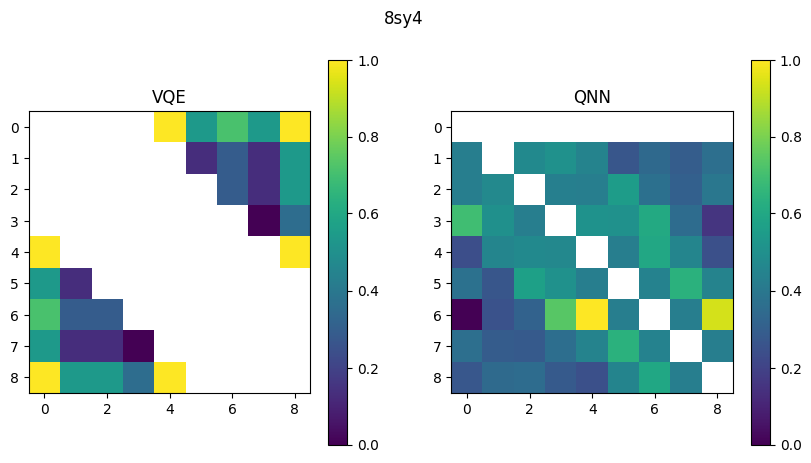

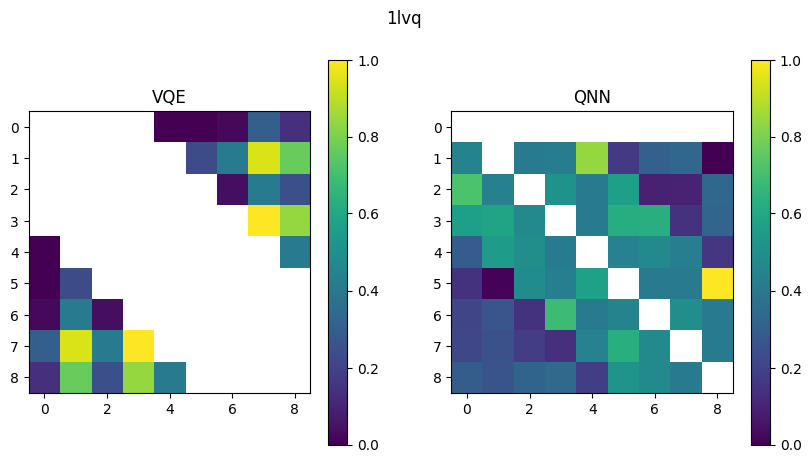

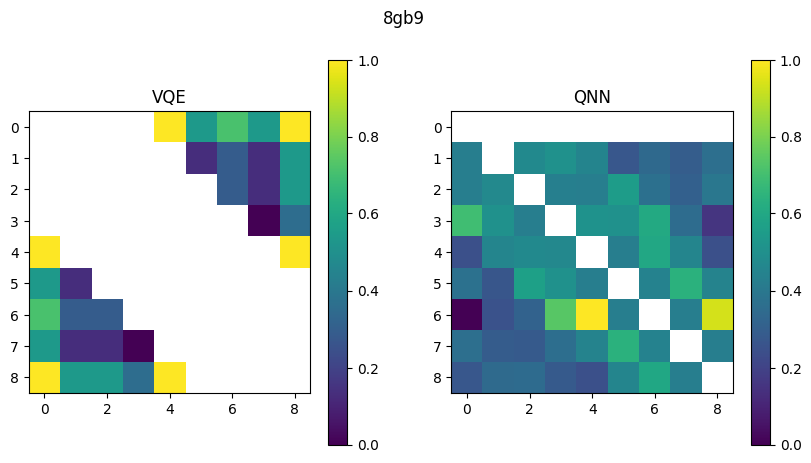

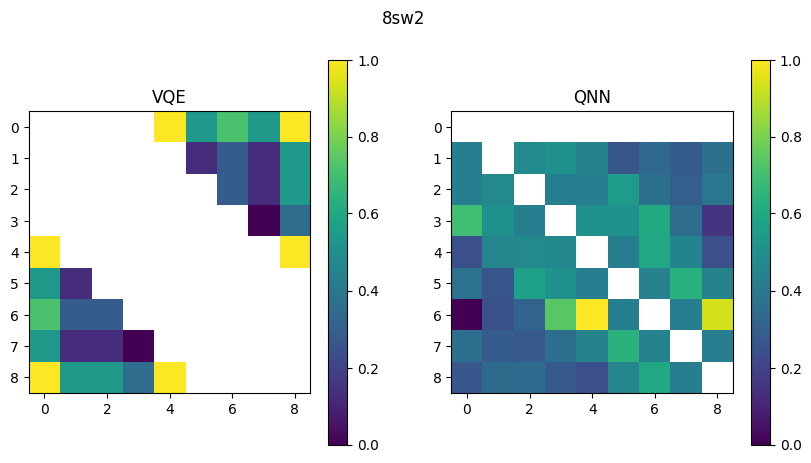

In [11]:
for pdb_id in tqdm(pdb_ids):
    vqe_matrix = vqe[pdb_id]
    qnn_matrix = np.stack([qnn[pdb_id].item()[i] for i in range(5)], axis=0).mean(axis=0)
    assert vqe_matrix.shape == qnn_matrix.shape
    
    for i in range(vqe_matrix.shape[0]):
        for j in range(i+1, vqe_matrix.shape[0]):
            vqe_matrix[j, i] = vqe_matrix[i, j]
    vqe_matrix = -vqe_matrix

    qnn_matrix[np.eye(qnn_matrix.shape[0], dtype=bool)] = 0

    # for vqe
    for i in range(vqe_matrix.shape[0]):
        for j in range(vqe_matrix.shape[1]):
            if np.isclose(vqe_matrix[i, j], 0):
                vqe_matrix[i, j] = np.nan

    # for qnn
    qnn_matrix[np.eye(qnn_matrix.shape[0], dtype=bool)] = np.nan
    qnn_matrix[0, :] = np.nan

    def scale_matrix(matrix):
        mask = np.ones_like(matrix, dtype=bool)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                if np.isnan(matrix[i, j]):
                    mask[i, j] = False
        
        value_matrix = matrix[mask]
        value_matrix = (value_matrix - value_matrix.min()) / (value_matrix.max() - value_matrix.min())
        matrix[mask] = value_matrix
        return matrix

    qnn_matrix = scale_matrix(qnn_matrix)
    vqe_matrix = scale_matrix(vqe_matrix)
    
    fig = plt.figure(figsize=(10, 5))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)
    
    im1 = ax1.imshow(vqe_matrix, cmap='viridis')
    im2 = ax2.imshow(qnn_matrix, cmap='viridis')
    
    ax1.set_title('VQE')
    ax2.set_title('QNN')
    fig.suptitle(pdb_id)
    
    fig.colorbar(im1, ax=ax1)
    fig.colorbar(im2, ax=ax2)
    
    fig.savefig(f'./figures/{pdb_id}.png')